# Loading Masks & Rendering Frames for Qwen3-VL
This jupyter notebook shows how to load individual masks and outline them for Qwen3-VL.

In [1]:
from load_data import load_frame_view, RenderedSample
from PIL import Image as PILImage

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


### Loading Individual Frames

In [2]:
MASKS_ROOT = "../"          # path to your replica_masks/ directory
RGB_ROOT   = "../data/replica/"     # path to Replica scene with color/ subdir
SCENE      = "room0"

In [3]:
frame0 = load_frame_view(SCENE, 0, masks_root=MASKS_ROOT, rgb_root=RGB_ROOT)

print(f"Label map shape: {frame0.label_map.shape}")
print(f"Masks found: {list(frame0.masks.keys())}")

Label map shape: (360, 640)
Masks found: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]


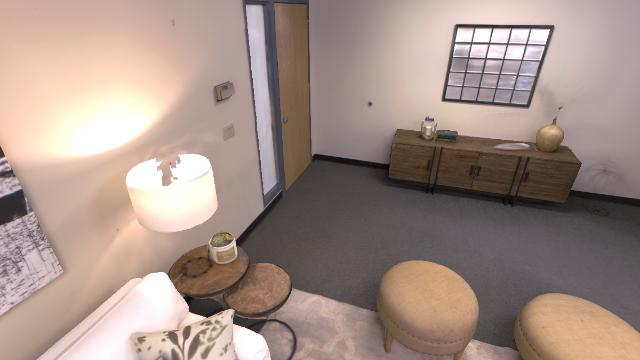

In [4]:
PILImage.fromarray(frame0.rgb)

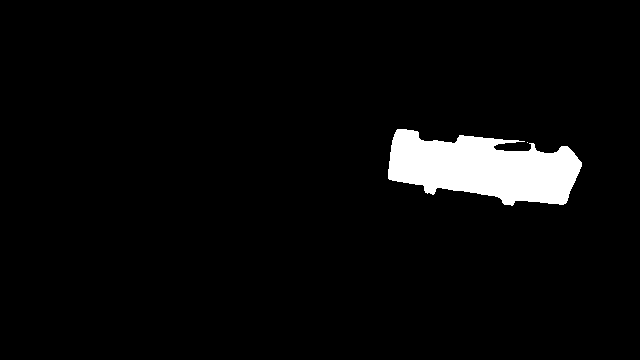

In [5]:
PILImage.fromarray(frame0.masks[8].binary_mask)

In [6]:
frame50 = load_frame_view(SCENE, 50, masks_root=MASKS_ROOT, rgb_root=RGB_ROOT)

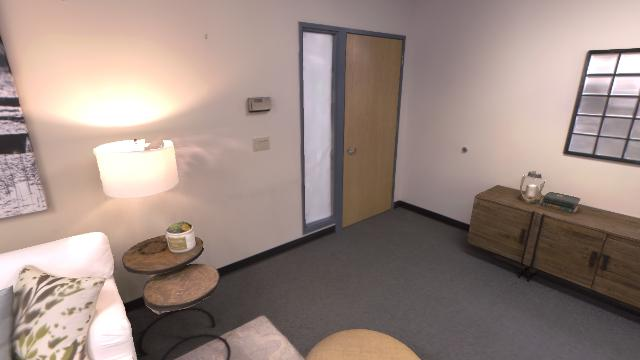

In [7]:
PILImage.fromarray(frame50.rgb)

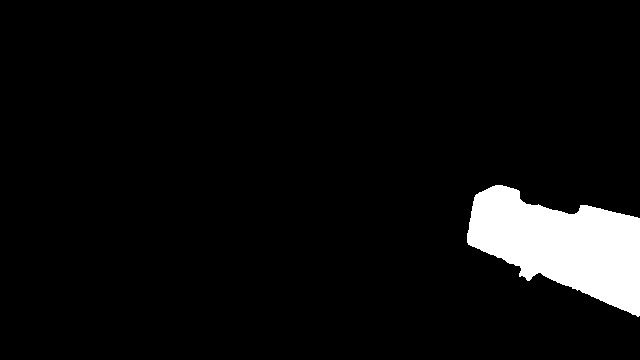

In [8]:
PILImage.fromarray(frame50.masks[6].binary_mask)

#### Positive Observer View

In [9]:
frame_pos = load_frame_view(SCENE, 10, masks_root=MASKS_ROOT, rgb_root=RGB_ROOT)

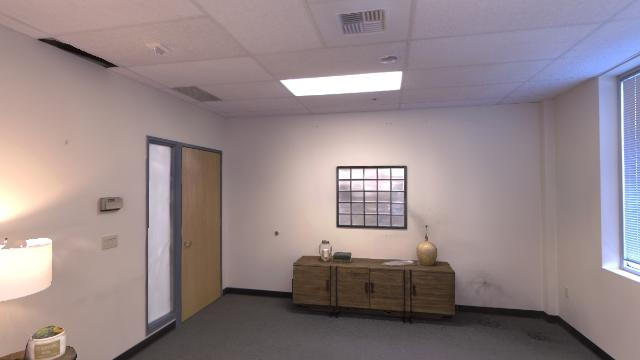

In [10]:
PILImage.fromarray(frame_pos.rgb)

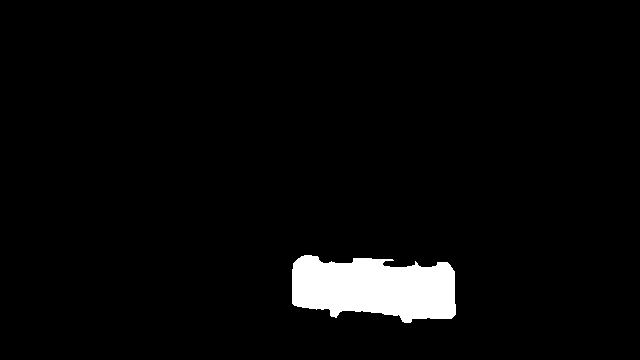

In [11]:
PILImage.fromarray(frame_pos.masks[6].binary_mask)

#### Negative Observer View

In [12]:
frame_neg = load_frame_view(SCENE, 80, masks_root=MASKS_ROOT, rgb_root=RGB_ROOT)

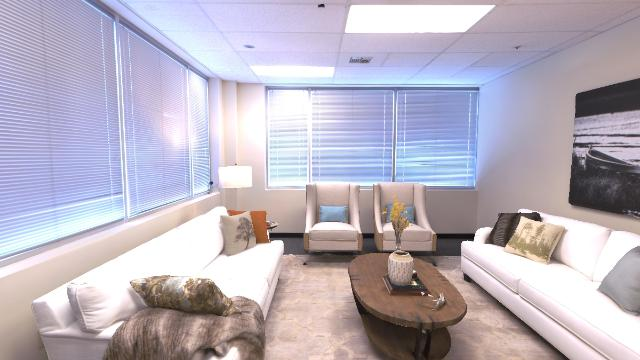

In [13]:
PILImage.fromarray(frame_neg.rgb)

## Rendering Data for Qwen3-VL

### Pair Only

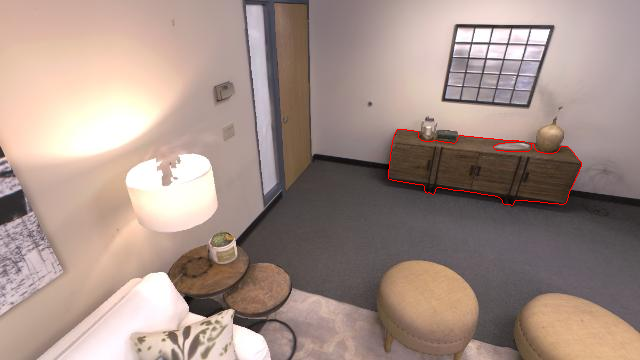

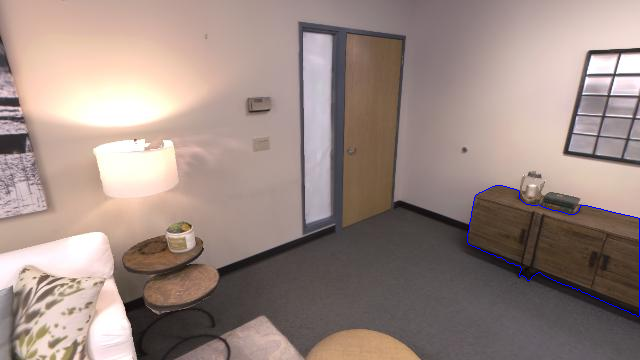

In [14]:
# Pick any two mask IDs present in this frame
sample = RenderedSample(
    condition="pair_only",
    frame_a=frame0,
    mask_id_a=8,
    frame_b=frame50,
    mask_id_b=6
)

view_a, view_b = sample.render()
display(view_a, view_b)

### Pair with Candidate

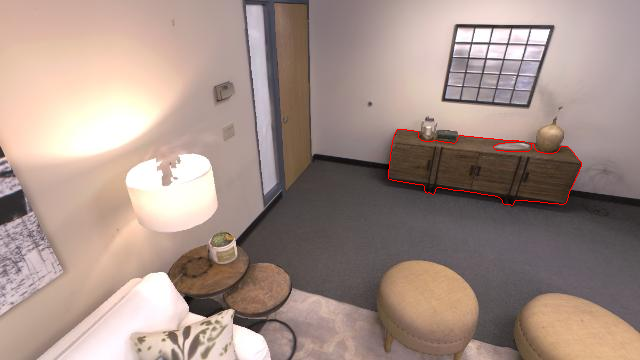

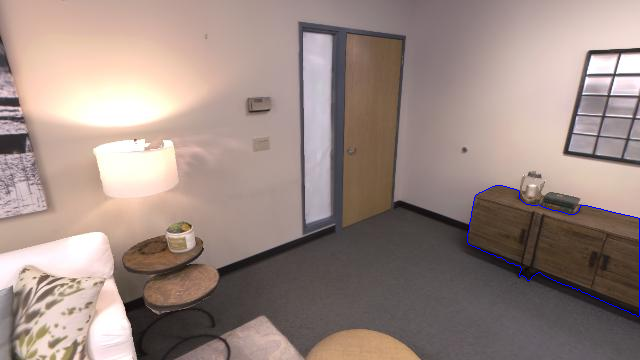

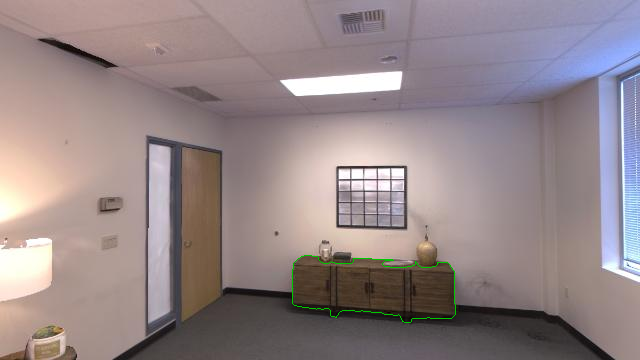

In [15]:
sample = RenderedSample(
    condition="pair_with_candidate",
    frame_a=frame0,
    mask_id_a=8,
    frame_b=frame50,
    mask_id_b=6, 
    observer=frame_pos,
    candidate_id=6,
)

view_a, view_b, candidate_view = sample.render()
display(view_a, view_b, candidate_view)

### Pair with All Masks

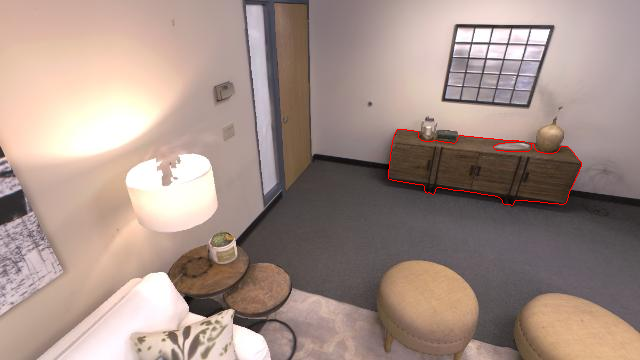

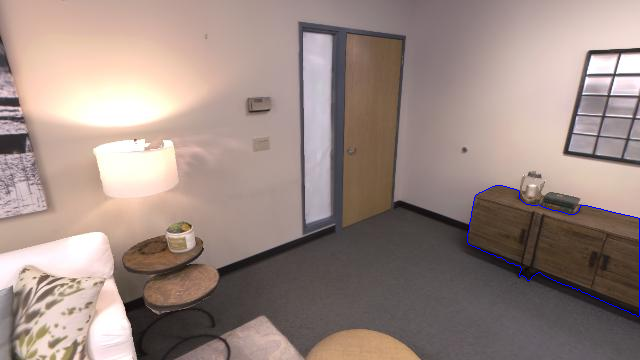

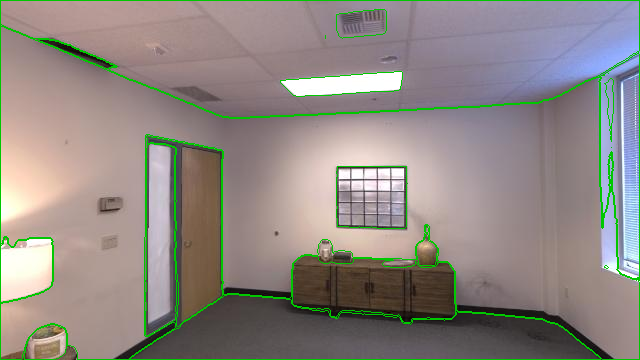

In [16]:
sample = RenderedSample(
    condition="pair_with_context",
    frame_a=frame0,
    mask_id_a=8,
    frame_b=frame50,
    mask_id_b=6, 
    observer=frame_pos
)

view_a, view_b, context_view = sample.render()
display(view_a, view_b, context_view)

## Loading GT
For training of the models, we need to know which masks belong to the same instance. Therefore we leverage the ground-truth from Replica dataset and:
* backproject masks back to 3D
* find the labels of the points in 3D
* based on majority vote: assign the instance label

In [17]:
# Need to go to the folder with the replica data folder

In [18]:
cd ..

/notebooks/ML3D-VLM_based_2D_mask_grouping/Project


In [19]:
ls

'Milestone 1'/   OpenYOLO3D.zip           myenv/                 start_env.sh
 Milestone_4/    data/                    replica/
 OpenYOLO3D/     get_replica_dataset.sh   replica_masks.tar.gz


In [20]:
frame0.assign_gt()

--- Assigning GT ---
	Loading Replica Dataset
	Backprojecting Masks back to 3D
	Ground-truth Loaded
	Assigning Ids based on majority vote
	Building gt_instance_id -> mask_id mapping
	Finished


In [21]:
frame0._gt_assigned

True

##### Check: If same GT ID is assigned

In [24]:
frame0.masks[8].gt_instance_id

18002

In [23]:
frame50.assign_gt()

--- Assigning GT ---
	Loading Replica Dataset
	Backprojecting Masks back to 3D
	Ground-truth Loaded
	Assigning Ids based on majority vote
	Building gt_instance_id -> mask_id mapping
	Finished


In [25]:
frame50.masks[6].gt_instance_id

18002